## About this fork

Based on [Tufa Labs’ Duck harness — June 30 milestone winner](https://www.kaggle.com/code/jeroencottaar/tufa-labs-duck-harness-june-30-milestone-winner). Full credit to Jeroen Cottaar and Tufa Labs for the original Duck solver and harness.

The Duck prompts, tool-use loop, game policy, and scorer remain unchanged. My changes are limited to model serving and performance:

- Replaced the original Qwen3.6-27B-FP8 serving stack with the pinned `RadixArk/Qwen3.8-Flash-Next-NVFP4` checkpoint.
- Inference optimization: ModelOpt NVFP4 weights, BF16 compute, async scheduling, chunked prefill, native three-token NEXTN MTP speculative decoding32K context, an 8K batched-token cap, eight vLLM sequences, CUDA graphs, disabled prefix caching, and disabled request/access logs. Duck retains 28-way game concurrency.
- Added a pinned offline vLLM runtime and compatibility patch required for the model’s FP8 PLE layers.
- Added an owned-server watchdog that checks `/v1/models`, restarts only after four consecutive failures, confirms the old process and port are gone, and permits at most two restarts.

# Tufa Labs ARC3 submission

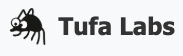

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
PUBLIC25_VLLM_PROFILE_NAME = 'kv5-bf16-mtp3-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "5368709120",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_BATCHED_TOKENS": "8192",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "3",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
# --- ENDURECIDO (kernel de experimento): localizar el wheelhouse recorriendo
# /kaggle/input (no fiarse de la ruta fija), reintento y stderr visible. El 2026-09-14
# esta celda murio dos veces con exit 1 porque la competencia no estaba montada en la
# ruta fija; la sonda arc-agi3-probe-mounts confirmo que en un kernel limpio si lo esta.
def _locate_wheelhouse():
    import os as _o
    _fijo = "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels"
    _hits = []
    for _dp, _dn, _fn in _o.walk("/kaggle/input"):
        if _dp.count(_o.sep) - "/kaggle/input".count(_o.sep) > 4:
            _dn[:] = []
            continue
        if "arc_agi_3_wheels" in _dn:
            _hits.append(_o.path.join(_dp, "arc_agi_3_wheels"))
    _elegido = _hits[0] if _hits else _fijo
    print(f"WHEELHOUSE_LOCATE hits={_hits} usado={_elegido} existe={_o.path.isdir(_elegido)}", flush=True)
    return _elegido


def _pip_install_retry(cmd, tries=3, wait_s=20):
    import time as _t
    last = None
    for _i in range(1, tries + 1):
        _r = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
        if _r.returncode == 0:
            print(f"WHEELHOUSE_INSTALL ok (intento {_i})", flush=True)
            return
        last = _r.stderr or ""
        print(f"WHEELHOUSE_INSTALL intento {_i} fallo (rc={_r.returncode}):\n{last[-1500:]}", flush=True)
        if _i < tries:
            _t.sleep(wait_s)
    _wh = "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels"
    try:
        import os as _o
        print("WHEELHOUSE_DIR", _wh, "existe:", _o.path.isdir(_wh),
              "entradas:", sorted(_o.listdir(_wh))[:12] if _o.path.isdir(_wh) else [], flush=True)
    except Exception as _e:
        print("WHEELHOUSE_DIR no listable:", _e, flush=True)
    raise RuntimeError(f"pip install arc-agi fallo {tries} veces; ultimo stderr:\n{last[-1500:]}")


_pip_install_retry(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        _locate_wheelhouse(),
        "arc-agi",
    ]
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands â€” installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts â€” the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Exact public-25 and competition settings.
bm.solver.max_runtime_s_per_game = 7920.0
bm.solver.analyzer_timeout = 900.0
bm.solver.concurrency = 28
bm.solver.max_actions_per_game = None
bm.solver.save_request_logs = False
if float(getattr(target, 'max_runtime_s', 0.0) or 0.0) != 32400.0:
    raise RuntimeError(
        f'Expected the 32400-second notebook budget, got {target.max_runtime_s!r}.'
    )
print(
    f'PUBLIC25_SETTINGS budget_s={bm.solver.max_runtime_s_per_game} '
    f'concurrency={bm.solver.concurrency} analyzer_timeout={bm.solver.analyzer_timeout} '
    f'action_cap={bm.solver.max_actions_per_game} request_logs={bm.solver.save_request_logs}',
    flush=True,
)


In [ ]:
# CONSOLIDACION v6 (CONTENIDO DE v5, FORMA DE v4) — kernel de EXPERIMENTO.
# v4 (contenido erroneo, forma narrativa) subio la mencion de la nota en el razonamiento al
# 31,9% frente al 11-15% de v1-v3. v5 (contenido CORRECTO -- mediana 10 celdas en vez de 44,
# 6,6% de objetos >=100 celdas en vez de 38,9% -- pero forma de inventario y con salvedad
# epistemica) la hundio al 9,4%: pareado 1-13 de 14 juegos contra v4, p=0,0018. Como v5
# conserva el vocabulario de objetos, lo que pagaba en v4 no era el vocabulario. v6 deja el
# contenido de v5 BYTE A BYTE (el modulo se genero sustituyendo solo la funcion que redacta,
# con test de equivalencia) y le devuelve la sintaxis de v4: secuencia con sujeto, verbo y
# consecuencia, sin la salvedad, con cierre imperativo.
try:
    import base64 as _b64n
    import inference.agent.tool_agent as _tan
    _nsn = {}
    exec(compile(_b64n.b64decode("IiIiQ29uc29saWRhY2lvbiB2NjogZWwgY29udGVuaWRvIGRlIHY1LCBjb250YWRvIGNvbW8gdjQgKG5hcnJhdGl2YSBjYXVzYWwpLg0KDQpQT1IgUVVFIChERVNJR04gOC42MykNCi0tLS0tLS0tLS0tLS0tLS0tLS0tLQ0KdjQgKGVmZWN0bywgY29udGVuaWRvIEVSUk9ORU8pIHN1YmlvIGxhIG1lbmNpb24gZGUgbGEgbm90YSBlbiBlbCByYXpvbmFtaWVudG8gYWwgMzEsOSUNCmZyZW50ZSBhbCAxMS0xNSUgZGUgdjEvdjIvdjMuIHY1IChwcmVjb25kaWNpb24sIGNvbnRlbmlkbyBDT1JSRUNUTzogbWVkaWFuYSAxMCBjZWxkYXMgZW4NCnZleiBkZSA0NCwgeSA2LDYlIGRlIG9iamV0b3MgPj0xMDAgY2VsZGFzIGVuIHZleiBkZSAzOCw5JSkgbGEgaHVuZGlvIGFsIDksNCU6IHBhcmVhZG8NCjEtMTMgZGUgMTQganVlZ29zIGNvbnRyYSB2NCAocD0wLDAwMTgpIGUgaW5kaXN0aW5ndWlibGUgZGUgdjEgKDUvNywgcD0wLDc3NCkuDQoNCkNvbW8gdjUgQ09OU0VSVkEgZWwgdm9jYWJ1bGFyaW8gZGUgb2JqZXRvcyB5IGF1biBhc2kgcGllcmRlIHRvZG8gZWwgZWZlY3RvLCBsbyBxdWUgcGFnYWJhDQplbiB2NCBubyBlcmEgZWwgdm9jYWJ1bGFyaW8uIFF1ZWRhbiB0cmVzIHNvc3BlY2hvc29zLCB5IHY2IGxvcyBwcnVlYmEganVudG9zIHBvcnF1ZSBzb24NCmV4YWN0YW1lbnRlIGxvIHF1ZSBzZXBhcmEgbGEgcmVkYWNjaW9uIGRlIHY0IGRlIGxhIGRlIHY1Og0KDQogMS4gbGEgTkFSUkFUSVZBIENBVVNBTDogInNlIG1vdmlvIFggeSBwYXNvIGEgdG9jYXIgWSIgKHN1amV0bywgdmVyYm8sIGNvbnNlY3VlbmNpYSkNCiAgICBmcmVudGUgYWwgaW52ZW50YXJpbyBkZSB2NSAoInJlc3BvbmRpYSBhIHR1cyBqdWdhZGFzOiBYOyBlbiBjb250YWN0byBjb246IFkiKTsNCiAyLiBsYSBTQUxWRURBRCBFUElTVEVNSUNBIHF1ZSBhbmFkaSBlbiB2NSBwb3IgaG9uZXN0aWRhZCAoImxvIGRlIGp1c3RvIGRlc3B1ZXMgbm8gc2UNCiAgICBwdWVkZSBvYnNlcnZhciIpLCB1bmljbyBlbGVtZW50byBxdWUgdjUgQU5BREUgZW4gdmV6IGRlIHF1aXRhcjsNCiAzLiBlbCBjaWVycmUgaW1wZXJhdGl2byAoInJlcGl0ZSBlc2EganVnYWRhIikgZnJlbnRlIGFsIGRlc2NyaXB0aXZvIGRlIHY1Lg0KDQpRVUUgTk8gQ0FNQklBOiBhYnNvbHV0YW1lbnRlIG5hZGEgZGVsIGNvbnRlbmlkby4gRXN0ZSBtb2R1bG8gc2UgR0VORVJPIGEgcGFydGlyIGRlDQpgbGV2ZWxfY2FycnlfcHJlLnB5YCBzdXN0aXR1eWVuZG8gVU5JQ0FNRU5URSBsYSBmdW5jaW9uIHF1ZSByZWRhY3RhOyB0b2RhIGxhIGV4dHJhY2Npb24NCihgb2JqZXRvX2NvbnRyb2xhZG9gLCBgb2JqZXRvX2Jham9fY2xpY2tgLCBgY29udGFjdG9zYCwgYGRlc2NyaWJpcl9wb3NpY2lvbmAsDQpgbWFyY2FzX3ZpY3RvcmlhYCB5IHN1cyBhdXhpbGlhcmVzKSBlcyBieXRlIGEgYnl0ZSBsYSBkZSB2NSwgeSBoYXkgdW4gdGVzdCBxdWUgbG8NCmNvbXBydWViYSBjb21wYXJhbmRvIGVsIGNvZGlnbyBmdWVudGUgeSBsYXMgc2FsaWRhcyBkZSBsb3MgZG9zIG1vZHVsb3MuDQoNCkhPTkVTVElEQUQgREUgTEEgUkVEQUNDSU9OOiB2NiBvcmRlbmEgZW4gc2VjdWVuY2lhIGhlY2hvcyBvYnNlcnZhZG9zIC0tIGVsIG9iamV0byByZXNwb25kaWENCmEgbGFzIGp1Z2FkYXMsIGVuIGVsIHRhYmxlcm8gcHJldmlvIGEgbGEgdmljdG9yaWEgZXN0YWJhIGVuIGNvbnRhY3RvIGNvbiB0YWwgb3RybywgeSBlbA0Kbml2ZWwgc2UgY29tcGxldG8gLS0gcGVybyBOTyBhZmlybWEgbmluZ3VuIGZvdG9ncmFtYSBpbnRlcm1lZGlvIHF1ZSBlbCBlbnRvcm5vIG5vIGVudHJlZ3VlLg0KRXMgbGEgbWlzbWEgaW5mb3JtYWNpb24gZGUgdjUgY29uIGxhIHNpbnRheGlzIGRlIHY0Lg0KIiIiDQoNCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMNCg0KSEFTSF9DT1JUTyA9IDgNCk1BWF9DRUxEQVMgPSAxIDw8IDE0DQojIEVsIGZvbmRvIHRhbWJpZW4gZXMgY29tcG9uZW50ZSBjb25leGEgeSBjYXNpIHNpZW1wcmUgbGEgbWF5b3I6IHNpbiBlc3RlIGZpbHRybyBlbA0KIyBwcm90YWdvbmlzdGEgc2FsZSAiVyBkZSAyNDcgY2VsZGFzIiBlbiB0b2RvcyBsb3MganVlZ29zIChidWcgY2F6YWRvIHBvciBsb3MgdGVzdHMgZGUNCiMgdjQpLiBTZSBkZXNjYXJ0YSBwb3IgQVJFQSwgbm8gcG9yIGNvbG9yOiBoYXkganVlZ29zIGNvbiBmb25kbyBuZWdybywgZ3JpcyBvIGRlIGNvbG9yLg0KRlJBQ0NJT05fRk9ORE8gPSAwLjIwDQoNCg0KZGVmIF9zZWdtZW50YXIoZ3JpZCk6DQogICAgaWYgbm90IGdyaWQ6DQogICAgICAgIHJldHVybiBOb25lDQogICAgZmlsYXMgPSBsZW4oZ3JpZCkNCiAgICBjb2xzID0gbGVuKGdyaWRbMF0pIGlmIGZpbGFzIGVsc2UgMA0KICAgIGlmIGZpbGFzICogY29scyA+IE1BWF9DRUxEQVM6DQogICAgICAgIHJldHVybiBOb25lDQogICAgdHJ5Og0KICAgICAgICBmcm9tIGluZmVyZW5jZS51dGlscy5zZWdtZW50YXRpb24gaW1wb3J0IHNlZ21lbnRfbGF5ZXINCiAgICAgICAgZnJvbSBpbmZlcmVuY2UudXRpbHMuZ3JpZF91dGlscyBpbXBvcnQgQVJDX0NPTE9SX0NIQVJTDQogICAgICAgIHJldHVybiBzZWdtZW50X2xheWVyKGdyaWQsIEFSQ19DT0xPUl9DSEFSUykNCiAgICBleGNlcHQgRXhjZXB0aW9uOg0KICAgICAgICByZXR1cm4gTm9uZQ0KDQoNCmRlZiBfY2FqYShuKToNCiAgICBiID0gbi5nZXQoImJvdW5kYXJ5Iikgb3IgW10NCiAgICBpZiBub3QgYjoNCiAgICAgICAgcmV0dXJuIE5vbmUNCiAgICBycyA9IFtwWzBdIGZvciBwIGluIGJdDQogICAgY3MgPSBbcFsxXSBmb3IgcCBpbiBiXQ0KICAgIHJldHVybiAobWluKHJzKSwgbWluKGNzKSwgbWF4KHJzKSwgbWF4KGNzKSkNCg0KDQpkZWYgX3Bvcl9oYXNoKHNlZykgLT4gZGljdDoNCiAgICBvdXQ6IGRpY3QgPSB7fQ0KICAgIGZvciBuIGluIHNlZ1sibm9kZXMiXToNCiAgICAgICAgb3V0LnNldGRlZmF1bHQoblsiaGFzaCJdLCBbXSkuYXBwZW5kKG4pDQogICAgcmV0dXJuIG91dA0KDQoNCmRlZiBfdmVjaW5vcyhzZWcsIG5vZG9faWQpIC0+IGxpc3Q6DQogICAgcG9yaWQgPSB7blsiaWQiXTogbiBmb3IgbiBpbiBzZWdbIm5vZGVzIl19DQogICAgb3V0ID0gW10NCiAgICBmb3IgaSwgaiBpbiBzZWcuZ2V0KCJhZGphY2VuY3lfbGlzdCIpIG9yIFtdOg0KICAgICAgICBvdHJvID0gaiBpZiBpID09IG5vZG9faWQgZWxzZSAoaSBpZiBqID09IG5vZG9faWQgZWxzZSBOb25lKQ0KICAgICAgICBpZiBvdHJvIGlzIG5vdCBOb25lIGFuZCBvdHJvIGluIHBvcmlkOg0KICAgICAgICAgICAgb3V0LmFwcGVuZChwb3JpZFtvdHJvXSkNCiAgICByZXR1cm4gb3V0DQoNCg0KZGVmIF9ldGlxdWV0YShuKSAtPiBzdHI6DQogICAgcmV0dXJuIGYie25bJ2NvbG9yJ119IGRlIHtuWydwaXhlbHMnXX0gY2VsZGFzIg0KDQoNCmRlZiBfY2VsZGFfY2xpY2soYWNjaW9uOiBzdHIpOg0KICAgIHQgPSBhY2Npb24gb3IgIiINCiAgICBpZiAicm93PSIgbm90IGluIHQgb3IgImNvbD0iIG5vdCBpbiB0Og0KICAgICAgICByZXR1cm4gTm9uZQ0KICAgIHRyeToNCiAgICAgICAgcmV0dXJuIChpbnQodC5zcGxpdCgicm93PSIsIDEpWzFdLnNwbGl0KCIsIiwgMSlbMF0uc3RyaXAoIikgIikpLA0KICAgICAgICAgICAgICAgIGludCh0LnNwbGl0KCJjb2w9IiwgMSlbMV0uc3BsaXQoIiwiLCAxKVswXS5zdHJpcCgiKSAiKSkpDQogICAgZXhjZXB0IChWYWx1ZUVycm9yLCBJbmRleEVycm9yKToNCiAgICAgICAgcmV0dXJuIE5vbmUNCg0KDQpkZWYgX2VzX2ZvbmRvKG4sIGNlbGRhcykgLT4gYm9vbDoNCiAgICByZXR1cm4gbi5nZXQoInBpeGVscyIsIDApID49IEZSQUNDSU9OX0ZPTkRPICogY2VsZGFzDQoNCg0KZGVmIG9iamV0b19jb250cm9sYWRvKGFudGVyaW9yX2dyaWQsIGFudGVzX2dyaWQpOg0KICAgICIiIkVsIG9iamV0byBxdWUgc2UgbW92aW8gZW50cmUgbG9zIGRvcyB1bHRpbW9zIHRhYmxlcm9zIERFTCBNSVNNTyBOSVZFTC4NCg0KICAgIEFtYm9zIGZvdG9ncmFtYXMgc29uIGRlbCBuaXZlbCBOLCBhc2kgcXVlIGFxdWkgbGEgZGlmZXJlbmNpYSBTSSBlcyBlbCBlZmVjdG8gZGUgdW5hDQogICAganVnYWRhIHJlYWwgKGEgZGlmZXJlbmNpYSBkZSB2MS12NCwgcXVlIGNydXphYmFuIGxhIGZyb250ZXJhIGRlIG5pdmVsKS4NCiAgICAiIiINCiAgICBzYSwgc2IgPSBfc2VnbWVudGFyKGFudGVyaW9yX2dyaWQpLCBfc2VnbWVudGFyKGFudGVzX2dyaWQpDQogICAgaWYgc2EgaXMgTm9uZSBvciBzYiBpcyBOb25lOg0KICAgICAgICByZXR1cm4gTm9uZQ0KICAgIGNlbGRhcyA9IHN1bShsZW4oZikgZm9yIGYgaW4gYW50ZXNfZ3JpZCkgb3IgMQ0KICAgIGhhLCBoYiA9IF9wb3JfaGFzaChzYSksIF9wb3JfaGFzaChzYikNCiAgICBtb3ZpZG9zID0gW10NCiAgICBmb3IgaCwgbmEgaW4gaGEuaXRlbXMoKToNCiAgICAgICAgbmIgPSBoYi5nZXQoaCkNCiAgICAgICAgaWYgbm90IG5iIG9yIGxlbihuYSkgIT0gMSBvciBsZW4obmIpICE9IDEgb3IgX2VzX2ZvbmRvKG5iWzBdLCBjZWxkYXMpOg0KICAgICAgICAgICAgY29udGludWUNCiAgICAgICAgY2EsIGNiID0gX2NhamEobmFbMF0pLCBfY2FqYShuYlswXSkNCiAgICAgICAgaWYgY2EgYW5kIGNiIGFuZCBjYSAhPSBjYjoNCiAgICAgICAgICAgIG1vdmlkb3MuYXBwZW5kKChuYlswXSwgKGNiWzBdIC0gY2FbMF0sIGNiWzFdIC0gY2FbMV0pKSkNCiAgICBpZiBub3QgbW92aWRvczoNCiAgICAgICAgcmV0dXJuIE5vbmUNCiAgICByZXR1cm4gbWF4KG1vdmlkb3MsIGtleT1sYW1iZGEgdDogdFswXS5nZXQoInBpeGVscyIsIDApKQ0KDQoNCmRlZiBvYmpldG9fYmFqb19jbGljayhhbnRlc19ncmlkLCBhY2Npb246IHN0cik6DQogICAgIiIiU29icmUgcXVlIG9iamV0byBhcHVudGFiYSBsYSBqdWdhZGEgZ2FuYWRvcmEsIHNpIGZ1ZSB1biBjbGljLiIiIg0KICAgIGNlbGRhID0gX2NlbGRhX2NsaWNrKGFjY2lvbikNCiAgICBpZiBjZWxkYSBpcyBOb25lOg0KICAgICAgICByZXR1cm4gTm9uZQ0KICAgIHNlZyA9IF9zZWdtZW50YXIoYW50ZXNfZ3JpZCkNCiAgICBpZiBzZWcgaXMgTm9uZToNCiAgICAgICAgcmV0dXJuIE5vbmUNCiAgICBjZWxkYXMgPSBzdW0obGVuKGYpIGZvciBmIGluIGFudGVzX2dyaWQpIG9yIDENCiAgICByLCBjID0gY2VsZGENCiAgICBtZWpvciA9IE5vbmUNCiAgICBmb3IgbiBpbiBzZWdbIm5vZGVzIl06DQogICAgICAgIGNhamEgPSBfY2FqYShuKQ0KICAgICAgICBpZiBub3QgY2FqYSBvciBfZXNfZm9uZG8obiwgY2VsZGFzKToNCiAgICAgICAgICAgIGNvbnRpbnVlDQogICAgICAgIHIwLCBjMCwgcjEsIGMxID0gY2FqYQ0KICAgICAgICBpZiByMCA8PSByIDw9IHIxIGFuZCBjMCA8PSBjIDw9IGMxOg0KICAgICAgICAgICAgaWYgbWVqb3IgaXMgTm9uZSBvciBuWyJwaXhlbHMiXSA8IG1lam9yWyJwaXhlbHMiXToNCiAgICAgICAgICAgICAgICBtZWpvciA9IG4gICAgICAgICAgIyBlbCBtYXMgYWp1c3RhZG8gYWwgcHVudG8sIG5vIGVsIGNvbnRlbmVkb3INCiAgICByZXR1cm4gbWVqb3INCg0KDQpkZWYgY29udGFjdG9zKGFudGVzX2dyaWQsIG5vZG8pOg0KICAgICIiIkNvbiBxdWUgZXN0YWJhIGVuIGNvbnRhY3RvIGVsIHByb3RhZ29uaXN0YSBlbiBlbCB0YWJsZXJvIGRlIGxhIHZpY3RvcmlhLiIiIg0KICAgIGlmIG5vZG8gaXMgTm9uZToNCiAgICAgICAgcmV0dXJuIFtdDQogICAgc2VnID0gX3NlZ21lbnRhcihhbnRlc19ncmlkKQ0KICAgIGlmIHNlZyBpcyBOb25lOg0KICAgICAgICByZXR1cm4gW10NCiAgICBjZWxkYXMgPSBzdW0obGVuKGYpIGZvciBmIGluIGFudGVzX2dyaWQpIG9yIDENCiAgICAjIGVsIG5vZG8gcHVlZGUgdmVuaXIgZGUgb3RyYSBzZWdtZW50YWNpb246IHNlIHJlbG9jYWxpemEgcG9yIGhhc2gNCiAgICBpZHMgPSBbblsiaWQiXSBmb3IgbiBpbiBzZWdbIm5vZGVzIl0gaWYgblsiaGFzaCJdID09IG5vZG9bImhhc2giXV0NCiAgICBpZiBub3QgaWRzOg0KICAgICAgICByZXR1cm4gW10NCiAgICBvdXQgPSBbbiBmb3IgbiBpbiBfdmVjaW5vcyhzZWcsIGlkc1swXSkgaWYgbm90IF9lc19mb25kbyhuLCBjZWxkYXMpXQ0KICAgIG91dC5zb3J0KGtleT1sYW1iZGEgbjogLW4uZ2V0KCJwaXhlbHMiLCAwKSkNCiAgICByZXR1cm4gb3V0WzoyXQ0KDQoNCmRlZiBkZXNjcmliaXJfcG9zaWNpb24oYW50ZXJpb3JfZ3JpZCwgYW50ZXNfZ3JpZCwgYWNjaW9uOiBzdHIpIC0+IGRpY3Q6DQogICAgIiIiVG9kbyBsbyBvYnNlcnZhYmxlIGRlbCBtb21lbnRvIGRlIGdhbmFyLCBzaW4gY3J1emFyIGxhIGZyb250ZXJhIGRlIG5pdmVsLiIiIg0KICAgIGN0cmwgPSBvYmpldG9fY29udHJvbGFkbyhhbnRlcmlvcl9ncmlkLCBhbnRlc19ncmlkKSBpZiBhbnRlcmlvcl9ncmlkIGVsc2UgTm9uZQ0KICAgIGNsaWMgPSBvYmpldG9fYmFqb19jbGljayhhbnRlc19ncmlkLCBhY2Npb24pDQogICAgcHJvdGFnb25pc3RhID0gKGN0cmxbMF0gaWYgY3RybCBlbHNlIE5vbmUpIG9yIGNsaWMNCiAgICByZXR1cm4geyJjb250cm9sYWRvIjogY3RybCwgImNsaWMiOiBjbGljLCAiY29udGFjdG9zIjogY29udGFjdG9zKGFudGVzX2dyaWQsIHByb3RhZ29uaXN0YSl9DQoNCg0KZGVmIHJlbmRlcl9ub3RhX25hcnJhdGl2YShuaXZlbF9hY3R1YWwsIG1hcmNhcykgLT4gc3RyOg0KICAgICIiIkxvcyBkYXRvcyBkZSB2NSwgY29uIGxhIHNpbnRheGlzIGRlIHY0OiB1bmEgc2VjdWVuY2lhLCBubyB1biBpbnZlbnRhcmlvLiIiIg0KICAgIHRyeToNCiAgICAgICAgbml2ZWxfYWN0dWFsID0gaW50KG5pdmVsX2FjdHVhbCkNCiAgICBleGNlcHQgKFR5cGVFcnJvciwgVmFsdWVFcnJvcik6DQogICAgICAgIHJldHVybiAiIg0KICAgIGlmIG5pdmVsX2FjdHVhbCA8PSAxIG9yIG5vdCBtYXJjYXM6DQogICAgICAgIHJldHVybiAiIg0KICAgIHVsdCA9IG1hcmNhc1stMV0NCiAgICBwb3MgPSB1bHQuZ2V0KCJwb3NpY2lvbiIpIG9yIHt9DQogICAgY3RybCwgY2xpYywgY29udCA9IHBvcy5nZXQoImNvbnRyb2xhZG8iKSwgcG9zLmdldCgiY2xpYyIpLCBwb3MuZ2V0KCJjb250YWN0b3MiKSBvciBbXQ0KICAgIGlmIG5vdCBjdHJsIGFuZCBub3QgY2xpYzoNCiAgICAgICAgcmV0dXJuICIiDQoNCiAgICBsaW5lYXMgPSBbZiJBU0kgR0FOQVNURSBlbCBuaXZlbCB7dWx0WyduaXZlbF9nYW5hZG8nXX0gIg0KICAgICAgICAgICAgICBmIihsZWlkbyBlbiBsYSBtaXNtYSBzZWdtZW50YWNpb24gcXVlIHZlcyk6Il0NCiAgICBjb250cmEgPSBjb250WzBdIGlmIGNvbnQgZWxzZSBOb25lDQogICAgaWYgY3RybCBpcyBub3QgTm9uZToNCiAgICAgICAgbiwgKGRyLCBkYykgPSBjdHJsDQogICAgICAgIHBhcnRlcyA9IFtdDQogICAgICAgIGlmIGRyOg0KICAgICAgICAgICAgcGFydGVzLmFwcGVuZChmInthYnMoZHIpfSBmaWxhcyIpDQogICAgICAgIGlmIGRjOg0KICAgICAgICAgICAgcGFydGVzLmFwcGVuZChmInthYnMoZGMpfSBjb2xzIikNCiAgICAgICAgcGFzbyA9ICIgeSAiLmpvaW4ocGFydGVzKSBvciAiZGUgc2l0aW8iDQogICAgICAgIGxpbmVhID0gKGYiLSBtb3Zpc3RlIGVsIG9iamV0byB7X2V0aXF1ZXRhKG4pfSAoaGFzaCB7blsnaGFzaCddWzpIQVNIX0NPUlRPXX0pLCAiDQogICAgICAgICAgICAgICAgIGYie3Bhc299IHBvciBqdWdhZGEiKQ0KICAgICAgICBpZiBjb250cmEgaXMgbm90IE5vbmU6DQogICAgICAgICAgICBsaW5lYSArPSBmIiwgaGFzdGEgcG9uZXJsbyBlbiBjb250YWN0byBjb24gZWwgb2JqZXRvIHtfZXRpcXVldGEoY29udHJhKX0iDQogICAgICAgIGxpbmVhcy5hcHBlbmQobGluZWEgKyAiLCB5IGVsIG5pdmVsIGNheW8iKQ0KICAgIGVsaWYgY2xpYyBpcyBub3QgTm9uZToNCiAgICAgICAgbGluZWEgPSBmIi0gY2xpY2FzdGUgc29icmUgZWwgb2JqZXRvIHtfZXRpcXVldGEoY2xpYyl9IChoYXNoIHtjbGljWydoYXNoJ11bOkhBU0hfQ09SVE9dfSkiDQogICAgICAgIGlmIGNvbnRyYSBpcyBub3QgTm9uZToNCiAgICAgICAgICAgIGxpbmVhICs9IGYiLCBxdWUgdG9jYWJhIGFsIG9iamV0byB7X2V0aXF1ZXRhKGNvbnRyYSl9Ig0KICAgICAgICBsaW5lYXMuYXBwZW5kKGxpbmVhICsgIiwgeSBlbCBuaXZlbCBjYXlvIikNCiAgICBpZiBjdHJsIGlzIG5vdCBOb25lIGFuZCBjbGljIGlzIG5vdCBOb25lIGFuZCBjbGljWyJoYXNoIl0gIT0gY3RybFswXVsiaGFzaCJdOg0KICAgICAgICBsaW5lYXMuYXBwZW5kKGYiLSBsYSBqdWdhZGEgZmluYWwgYXB1bnRvIHNvYnJlIGVsIG9iamV0byB7X2V0aXF1ZXRhKGNsaWMpfSAiDQogICAgICAgICAgICAgICAgICAgICAgZiIoaGFzaCB7Y2xpY1snaGFzaCddWzpIQVNIX0NPUlRPXX0pIikNCiAgICBpZiBsZW4obWFyY2FzKSA+IDE6DQogICAgICAgIGxpbmVhcy5hcHBlbmQoZiItIChhbnRlcyBnYW5hc3RlIHtsZW4obWFyY2FzKSAtIDF9IG5pdmVsKGVzKSBtYXMpIikNCiAgICBsaW5lYXMuYXBwZW5kKCJSZXBpdGUgZXNhIGp1Z2FkYSBhcXVpOiBidXNjYSBsb3MgbWlzbW9zIG9iamV0b3MgcG9yIGNvbG9yK2NlbGRhcyBvICINCiAgICAgICAgICAgICAgICAgICJwcmVmaWpvIGRlIGhhc2ggeSBsbGV2YWxvcyBhIGxhIG1pc21hIHJlbGFjaW9uLiIpDQogICAgcmV0dXJuICdcbicuam9pbihsaW5lYXMpDQoNCg0KZGVmIF9uaXZlbChmcmFtZSkgLT4gaW50Og0KICAgIHRyeToNCiAgICAgICAgcmV0dXJuIGludChnZXRhdHRyKGZyYW1lLCAibGV2ZWwiLCAxKSBvciAxKQ0KICAgIGV4Y2VwdCAoVHlwZUVycm9yLCBWYWx1ZUVycm9yKToNCiAgICAgICAgcmV0dXJuIDENCg0KDQpkZWYgX2dyaWQoZnJhbWUpOg0KICAgIGcgPSBnZXRhdHRyKGZyYW1lLCAiZ3JpZCIsIE5vbmUpDQogICAgcmV0dXJuIGcgaWYgZyBlbHNlICgpDQoNCg0KZGVmIG1hcmNhc192aWN0b3JpYShoaXN0b3J5X2VudHJpZXMpIC0+IGxpc3RbZGljdF06DQogICAgIiIiVW4gcmVnaXN0cm8gcG9yIG5pdmVsIGNvbXBsZXRhZG8uIFNvbG8gc2UgYW5hbGl6YSBlbCB1bHRpbW8sIHkgU09MTyBjb24NCiAgICBmb3RvZ3JhbWFzIGRlbCBuaXZlbCBOOiBgYW50ZXNgIGVzIGVsIHVsdGltbyB0YWJsZXJvIGRlbCBuaXZlbCB5IGBhbnRlcmlvcmAgZWwNCiAgICBwZW51bHRpbW8uIE51bmNhIHNlIHRvY2EgZWwgcHJpbWVyIHRhYmxlcm8gZGVsIG5pdmVsIHNpZ3VpZW50ZS4iIiINCiAgICBtYXJjYXM6IGxpc3RbZGljdF0gPSBbXQ0KICAgIGlmIG5vdCBoaXN0b3J5X2VudHJpZXM6DQogICAgICAgIHJldHVybiBtYXJjYXMNCiAgICBuaXZlbF9wcmV2ID0gMQ0KICAgIGZyYW1lX3ByZXYgPSBOb25lDQogICAgZnJhbWVfcHJldjIgPSBOb25lDQogICAgZm9yIGUgaW4gaGlzdG9yeV9lbnRyaWVzOg0KICAgICAgICBmciA9IGdldGF0dHIoZSwgImZyYW1lIiwgTm9uZSkNCiAgICAgICAgaWYgZnIgaXMgTm9uZToNCiAgICAgICAgICAgIGNvbnRpbnVlDQogICAgICAgIG5pdiA9IF9uaXZlbChmcikNCiAgICAgICAgaWYgbml2ID4gbml2ZWxfcHJldjoNCiAgICAgICAgICAgICMgZnJhbWVfcHJldiB5IGZyYW1lX3ByZXYyIHNvbiBkZWwgbml2ZWwgcXVlIHNlIGFjYWJhIGRlIGdhbmFyDQogICAgICAgICAgICBhbnRlcmlvciA9IGZyYW1lX3ByZXYyIGlmIChmcmFtZV9wcmV2MiBpcyBub3QgTm9uZSBhbmQgZnJhbWVfcHJldiBpcyBub3QgTm9uZQ0KICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgYW5kIF9uaXZlbChmcmFtZV9wcmV2MikgPT0gX25pdmVsKGZyYW1lX3ByZXYpKSBlbHNlIE5vbmUNCiAgICAgICAgICAgIG1hcmNhcy5hcHBlbmQoew0KICAgICAgICAgICAgICAgICJuaXZlbF9nYW5hZG8iOiBuaXZlbF9wcmV2LA0KICAgICAgICAgICAgICAgICJhY2Npb24iOiAiICIuam9pbihzdHIoZ2V0YXR0cihlLCAiYWN0aW9uIiwgIiIpIG9yICIiKS5zcGxpdCgpKSwNCiAgICAgICAgICAgICAgICAiYW50ZXJpb3IiOiBhbnRlcmlvciwNCiAgICAgICAgICAgICAgICAiYW50ZXMiOiBmcmFtZV9wcmV2LA0KICAgICAgICAgICAgfSkNCiAgICAgICAgICAgIG5pdmVsX3ByZXYgPSBuaXYNCiAgICAgICAgICAgIGZyYW1lX3ByZXYyID0gTm9uZQ0KICAgICAgICAgICAgZnJhbWVfcHJldiA9IGZyDQogICAgICAgICAgICBjb250aW51ZQ0KICAgICAgICBmcmFtZV9wcmV2MiA9IGZyYW1lX3ByZXYNCiAgICAgICAgZnJhbWVfcHJldiA9IGZyDQogICAgaWYgbm90IG1hcmNhczoNCiAgICAgICAgcmV0dXJuIG1hcmNhcw0KICAgIHVsdCA9IG1hcmNhc1stMV0NCiAgICB1bHRbInBvc2ljaW9uIl0gPSBkZXNjcmliaXJfcG9zaWNpb24oX2dyaWQodWx0WyJhbnRlcmlvciJdKSBpZiB1bHRbImFudGVyaW9yIl0gZWxzZSBOb25lLA0KICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBfZ3JpZCh1bHRbImFudGVzIl0pIGlmIHVsdFsiYW50ZXMiXSBlbHNlICgpLA0KICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICB1bHQuZ2V0KCJhY2Npb24iLCAiIikpDQogICAgcmV0dXJuIG1hcmNhcw0K").decode("utf-8"), "level_carry_nar.py", "exec"), _nsn)
    _marcas_nar = _nsn["marcas_victoria"]
    _render_nar = _nsn["render_nota_narrativa"]
    _orig_bup_n = _tan.ToolAgent._build_user_prompt

    def _bup_with_nar(self, action_num, **kw):
        base = _orig_bup_n(self, action_num, **kw)
        try:
            fr = kw.get("current_frame")
            nivel = int(getattr(fr, "level", 1) or 1) if fr is not None else 1
            nota = _render_nar(nivel, _marcas_nar(kw.get("history_entries") or []))
        except Exception:
            return base
        return base + "\n" + nota if nota else base

    _tan.ToolAgent._build_user_prompt = _bup_with_nar
    print("LEVEL_CARRY_NAR injected on seam C:", len(_nsn), "symbols", flush=True)
except Exception as exc:
    print("[level_carry_nar] injection failed, running stock: %s: %s" % (type(exc).__name__, exc), flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise â€” an interactive "Save & Run" â€” play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Skip pre-run display and git-status copies; the staged identity pins the run.

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

PUBLIC_GAME_IDS = tuple([
    "tn36-ef4dde99",
    "lf52-271a04aa",
    "cn04-2fe56bfb",
    "bp35-0a0ad940",
    "wa30-ee6fef47",
    "lp85-305b61c3",
    "r11l-495a7899",
    "tu93-0768757b",
    "sp80-589a99af",
    "m0r0-492f87ba",
    "vc33-5430563c",
    "ar25-0c556536",
    "ka59-38d34dbb",
    "sc25-635fd71a",
    "sk48-d8078629",
    "dc22-fdcac232",
    "cd82-fb555c5d",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ls20-9607627b",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "su15-1944f8ab",
    "tr87-cd924810"
])

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    offline_games = _offline_games(competition_env_files)
    offline_by_id = {game.env_name: game for game in offline_games}
    if len(offline_by_id) != len(offline_games):
        raise RuntimeError('The offline public game list contains duplicate IDs.')
    missing = sorted(set(PUBLIC_GAME_IDS) - set(offline_by_id))
    extra = sorted(set(offline_by_id) - set(PUBLIC_GAME_IDS))
    if missing or extra:
        raise RuntimeError(
            f'Offline public game set changed; missing={missing}, extra={extra}.'
        )
    bm.games = [offline_by_id[game_id] for game_id in PUBLIC_GAME_IDS]
    if len(bm.games) != 25:
        raise RuntimeError(f'Expected 25 public games, got {len(bm.games)}.')
    print(f'PUBLIC25_SELECTION games={len(bm.games)} passes=1', flush=True)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
if budget <= 600.0:
    raise RuntimeError(f'Notebook budget is too small for the teardown reserve: {budget}.')
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=budget - 600.0
)
# --- UNICA EDICION SOBRE EL NOTEBOOK PUBLICO DE keithtyser ---------------
# En Save & Run (no rerun) el presupuesto son 8h50m y se comeria la cuota de G4
# entera. Se recorta la ventana OFFLINE a TAAF_OFFLINE_SOFT_MIN minutos. En el
# rerun real (TRUE_SUBMISSION) no se toca nada: el presupuesto queda intacto.
if not TRUE_SUBMISSION:
    _soft_min = float(os.environ.get("TAAF_OFFLINE_SOFT_MIN", "60"))
    soft_end = min(
        soft_end,
        datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(minutes=_soft_min),
    )
    print(f"OFFLINE_CUT soft_min={_soft_min} soft_end={soft_end}", flush=True)
# ------------------------------------------------------------------------

# Start recovery only after setup readiness and all run gates pass.
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))
import vllm_server_watchdog as vllm_watchdog

vllm_watchdog_setup = vllm_watchdog.load_setup(BUNDLE_DIR / 'serving_setup.py')
vllm_watchdog.start_background(
    vllm_watchdog_setup,
    vllm_watchdog.WatchdogConfig(
        interval_seconds=15.0,
        request_timeout_seconds=5,
        failure_threshold=4,
        max_restart_attempts=2,
    ),
)

# Play the benchmark; watchdog stop and teardown run even if it raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=True)
    bm._save_json()
    if not TRUE_SUBMISSION:
        # Kaggle Save & Run expects this valid placeholder after an offline run.
        # A real competition rerun uses the live gateway and never enters this branch.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)

        # Check terminal coverage, then call the frozen scorer once.
        # This path does not render HTML.
        public_runs = list(bm.game_runs)
        public_run_ids = [run.game_id for run in public_runs]
        if len(public_runs) != 25 or public_run_ids != list(PUBLIC_GAME_IDS):
            raise RuntimeError(
                f'Public run coverage changed: count={len(public_runs)} ids={public_run_ids}.'
            )
        unfinished = [
            (run.game_id, run.state, run.final_score)
            for run in public_runs
            if run.state not in {'won', 'gave_up', 'cancelled'}
            or run.final_score is None
        ]
        if unfinished:
            raise RuntimeError(f'Public runs did not finalize cleanly: {unfinished}.')
        crashed = [run.game_id for run in public_runs if run.state == 'crashed']
        if crashed:
            raise RuntimeError(f'Public runs crashed: {crashed}.')
        total_actions = sum(len(run.history) for run in public_runs)
        if total_actions <= 0:
            raise RuntimeError('Public runs produced no actions.')

        from inference.tools.eval import evaluate_runs, save_score_file

        score_summary = evaluate_runs([WORKING_DIR])
        score_path = save_score_file(
            score_summary,
            run_dirs=[WORKING_DIR],
            output_path=WORKING_DIR / "score.json",
        )
        if Path(score_path) != WORKING_DIR / 'score.json' or not Path(score_path).is_file():
            raise RuntimeError(f'Frozen scorer did not write score.json: {score_path}.')
        print(
            f'PUBLIC25_AUDIT runs=25 actions={total_actions} score_path={score_path}',
            flush=True,
        )
finally:
    try:
        vllm_watchdog.stop_background(timeout_seconds=15.0)
    finally:
        for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
            print(f"taaf.kaggle: teardown command: {command}", flush=True)
            subprocess.run(
                command,
                shell=True,
                check=False,
                cwd=WORKING_DIR,
                env=_command_env(),
                timeout=30.0,
            )


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
# Minimal diagnostics are enabled; skip post-run HTML rendering.
